# Ridge Regresija — Predikcija Cena Automobila

## Struktura

| # | Sekcija | Opis |
|---|---------|------|
| 1 | **Data Loading & Overview** | Uvoz podataka, tipovi, null-ovi, statistika |
| 2 | **Feature Engineering** | Outlier analiza, ciklicni mesec, drop redundantnih kolona |
| 3 | **Train/Test Split + Log transformacija** | Split 80/20, log(price) motivacija i primena |
| 4 | **Preprocessing Pipeline** | make_preprocessor() fabrika, TargetEncoder, OHE+Scaler, StandardScaler |
| 5 | **Baseline Model** | LinearRegression kao referentna tacka |
| 6 | **Ridge + GridSearchCV** | Prosireni alpha grid, 5-fold CV, analiza regularizacije |
| 7 | **Evaluacija i Vizualizacije** | MAE, RMSE, R2, MAPE, Smearing korekcija, analiza rezidualnih |
| 8 | **Analiza gresaka po segmentu** | Greska po cenovnom segmentu (Budget/Mid/Premium/Luxury) |
| 9 | **Interpretacija Koeficijenata** | Koeficijenti u log prostoru -> ekonomska interpretacija |
| 10 | **Cuvanje Pipeline-a** | joblib serijalizacija + produkciona napomena |
| 11 | **PCA Eksperiment** | Redukcija dimenzionalnosti vs originalni prostor |


## 1. Data Loading & Overview

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold, RepeatedKFold, StratifiedKFold
np.random.seed(42)

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

BASE_DIR = Path.cwd()
PROCESSED_DATA_PATH = BASE_DIR.parent / "DataSet" / "processed" / "procesirani_podaci.csv"
MODELS_DIR = BASE_DIR.parent / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Kolone: {list(df.columns)}")
df.head()


Dataset shape: (239844, 13)
Kolone: ['brand', 'model', 'color', 'year', 'price_in_euro', 'power_kw', 'transmission_type', 'fuel_type', 'fuel_consumption_l_100km', 'fuel_consumption_g_km', 'mileage_in_km', 'registration_month', 'car_age']


,brand,model,color,year,price_in_euro,power_kw,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age
0,alfa-romeo,alfa romeo gtv,red,1995.0,1300.0,148.0,manual,petrol,10.9,260.0,160500.0,10.0,31.0
1,alfa-romeo,alfa romeo 164,black,1995.0,24900.0,191.0,manual,petrol,5.7,135.0,190000.0,2.0,31.0
2,alfa-romeo,alfa romeo spider,black,1995.0,4900.0,110.0,manual,petrol,9.5,225.0,189500.0,7.0,31.0
3,alfa-romeo,alfa romeo 164,red,1996.0,17950.0,132.0,manual,petrol,7.2,135.0,96127.0,11.0,30.0
4,alfa-romeo,alfa romeo spider,red,1996.0,7900.0,110.0,manual,petrol,9.5,225.0,47307.0,4.0,30.0


In [69]:
print('-- Tipovi podataka --')
print(df.dtypes)
print()
print('-- Nedostajuce vrednosti --')
print(df.isnull().sum())
print()
print('-- Osnovna statistika --')
df.describe().round(2)


-- Tipovi podataka --
brand                           str
model                           str
color                           str
year                        float64
price_in_euro               float64
power_kw                    float64
transmission_type               str
fuel_type                       str
fuel_consumption_l_100km    float64
fuel_consumption_g_km       float64
mileage_in_km               float64
registration_month          float64
car_age                     float64
dtype: object

-- Nedostajuce vrednosti --
brand                       0
model                       0
color                       0
year                        0
price_in_euro               0
power_kw                    0
transmission_type           0
fuel_type                   0
fuel_consumption_l_100km    0
fuel_consumption_g_km       0
mileage_in_km               0
registration_month          0
car_age                     0
dtype: int64

-- Osnovna statistika --


,year,price_in_euro,power_kw,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age
count,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00
mean,2016.12,24936.46,125.80,6.02,141.25,87019.75,6.30,9.88
std,5.45,25141.76,69.73,1.80,55.37,75092.81,3.38,5.45
min,1995.00,500.00,25.00,0.50,0.00,0.00,1.00,3.00
25%,2013.00,11900.00,84.00,5.00,119.00,27408.75,3.00,6.00
50%,2018.00,19500.00,110.00,5.70,135.00,69978.00,6.00,8.00
75%,2020.00,29850.00,140.00,6.60,157.00,129000.00,9.00,13.00
max,2023.00,300000.00,596.00,30.00,2018.00,500000.00,12.00,31.00


In [70]:
print(f"Transmission types ({df['transmission_type'].nunique()}): {df['transmission_type'].unique().tolist()}")
print(f"Fuel types ({df['fuel_type'].nunique()}): {df['fuel_type'].unique().tolist()}")
print(f"Colors:  {df['color'].nunique()} jedinstvenih")
print(f"Brands:  {df['brand'].nunique()} jedinstvenih")
print(f"Models:  {df['model'].nunique()} jedinstvenih")


Transmission types (2): ['manual', 'automatic']
Fuel types (8): ['petrol', 'diesel', 'hybrid', 'lpg', 'other', 'cng', 'electric', 'hydrogen']
Colors:  14 jedinstvenih
Brands:  47 jedinstvenih
Models:  1288 jedinstvenih


## 2. Feature Engineering

### Sta se radi i zasto

| Korak | Feature | Akcija | Razlog |
|-------|---------|--------|--------|
| 1 | `year` | Drop | `car_age` nosi identicnu informaciju |
| 2 | `fuel_consumption_g_km` | Drop | Anomalije (max=2018.0 greska unosa) + redundantnost sa l/100km |
| 3 | `registration_month` | month_sin + month_cos | Ciklicna varijabla |


In [71]:
if 'year' in df.columns:
    df = df.drop(columns=['year'])
else:
    print("'year' vec nije prisutan u datasetu.")
print(f'Shape: {df.shape}')


Shape: (239844, 12)


In [86]:
if 'fuel_consumption_g_km' in df.columns:
    print('-- Analiza: fuel_consumption_g_km --')
    anomalije = df[df['fuel_consumption_g_km'] > 500]
    print(f'Redovi sa g_km > 500 (anomalije): {len(anomalije)}')
    print(f"Maksimalna vrednost g_km: {df['fuel_consumption_g_km'].max():.1f}")
    if len(anomalije) > 0:
        print(anomalije[['brand', 'model', 'fuel_consumption_g_km', 'fuel_consumption_l_100km']].head(5))
    corr = df['fuel_consumption_l_100km'].corr(df['fuel_consumption_g_km'])
    shared_variance_pct = corr**2 * 100
    print(f'Pearsonova korelacija l/100km vs g/km: {corr:.4f}')
    print(f'Zajednička varijansa (R2): {shared_variance_pct:.1f}% — veoma visoko korelisane i verovatno redundantne za linearni model')
    df = df.drop(columns=['fuel_consumption_g_km'])
    print(f"\n'fuel_consumption_g_km' uklonjen. Shape: {df.shape}")
else:
    print("'fuel_consumption_g_km' vec nije prisutan — celija je idempotentna, nema greske.")
    print(f'Trenutni shape: {df.shape}')


-- Analiza: fuel_consumption_g_km --
Redovi sa g_km > 500 (anomalije): 242
Maksimalna vrednost g_km: 2018.0
      brand           model  fuel_consumption_g_km  fuel_consumption_l_100km
20210  audi            audi                  501.0                       5.7
21221  audi  audi q4 e-tron                  530.0                       5.7
21555  audi            audi                  542.0                       5.7
21645  audi  audi q8 e-tron                  518.0                       5.7
21953  audi     audi e-tron                  505.0                       5.7
Pearsonova korelacija l/100km vs g/km: 0.6602
Zajednička varijansa (R2): 43.6% — veoma visoko korelisane i verovatno redundantne za linearni model

'fuel_consumption_g_km' uklonjen. Shape: (239844, 12)


In [87]:
if 'registration_month' in df.columns:
    invalid_months = df[~df['registration_month'].between(1, 12)]
    print(f'Nevalidni meseci: {len(invalid_months)}')
df['month_sin'] = np.sin(2 * np.pi * df['registration_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['registration_month'] / 12)
df = df.drop(columns=['registration_month'])
print('registration_month -> month_sin + month_cos (ciklicno enkodovanje)')
print(f'Shape: {df.shape}')
print(f'Kolone: {list(df.columns)}')


Nevalidni meseci: 0
registration_month -> month_sin + month_cos (ciklicno enkodovanje)
Shape: (239844, 13)
Kolone: ['brand', 'model', 'color', 'year', 'price_in_euro', 'power_kw', 'transmission_type', 'fuel_type', 'fuel_consumption_l_100km', 'mileage_in_km', 'car_age', 'month_sin', 'month_cos']


## 3. Train/Test Split + Log-transformacija targeta

### Zasto log(price)?

| Problem | Uzrok | Fix |
|---------|-------|-----|
| Negativne predikcije | Cena je log-normalna, Ridge je linearan | log(price) -> exp(pred) uvek pozitivan |
| Heteroskedasticnost | Varijansa raste sa cenom | Log normalizuje varijansu |
| Slabije metrike za skupe aute | Model minimizuje apsolutnu gresku | Log daje proporcionalne greske |

> **Napomena — Log-bias (Jensen's inequality):**
> E[exp(y_hat)] != exp(E[y_hat]) — model sistematski potcenjuje stvarne cene.
> Koriguje se Smearing estimatorom.
>
> **Vazno:** Smearing faktor se mora izracunati na **train rezidualima**, ne test rezidualima.
> Korisćenje test reziduala je data leakage i ne bi radilo u produkciji.


In [90]:
TARGET = 'price_in_euro'
X = df.drop(columns=[TARGET])
y = df[TARGET]

y_bins = pd.qcut(y, q=10, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_bins
)

y_train_log = np.log(y_train)
y_test_log  = np.log(y_test)
print('Distribucija target binova u train/test je ocuvana stratifikacijom.')
print(X_train.shape, y_train.shape)
print(X_test.shape,y_test.shape)


Distribucija target binova u train/test je ocuvana stratifikacijom.
(191875, 12) (191875,)
(47969, 12) (47969,)


## 4. Preprocessing Pipeline

### Strategija enkodovanja

| Grupa | Transformer(i) | Razlog |
|-------|---------------|--------|
| `brand`, `model` | TargetEncoder + StandardScaler | Visoka kardinalnost (47 brendova, 1288 modela) |
| `transmission_type`, `fuel_type`, `color` | OneHotEncoder + StandardScaler | Niska kardinalnost; skaliranje za ravnomernu L2 regularizaciju |
| Numericke + month_sin/cos | StandardScaler | Razlicite skale (kW vs km vs godine) |


In [75]:
TARGET_ENC_COLS = ['brand', 'model']
OHE_COLS        = ['transmission_type', 'fuel_type', 'color']
NUM_COLS        = [c for c in X_train.columns if c not in TARGET_ENC_COLS + OHE_COLS]
print('Target Encoded (visoka kardinalnost):', TARGET_ENC_COLS)
print('One-Hot Encoded (niska kardinalnost):', OHE_COLS)
print('Numericki (StandardScaler):', NUM_COLS)
print(f'\nUkupno: {len(TARGET_ENC_COLS)} TE + {len(OHE_COLS)} OHE grupe + {len(NUM_COLS)} numerickih')


Target Encoded (visoka kardinalnost): ['brand', 'model']
One-Hot Encoded (niska kardinalnost): ['transmission_type', 'fuel_type', 'color']
Numericki (StandardScaler): ['power_kw', 'fuel_consumption_l_100km', 'mileage_in_km', 'car_age', 'month_sin', 'month_cos']

Ukupno: 2 TE + 3 OHE grupe + 6 numerickih


In [93]:
def make_preprocessor():
    target_enc_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', TargetEncoder(target_type='continuous')),
        ('scaler', StandardScaler()),
    ])

    ohe_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
        ('scaler', StandardScaler()),
    ])

    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])

    return ColumnTransformer(
        transformers=[
            ('target_enc', target_enc_pipe, TARGET_ENC_COLS),
            ('ohe', ohe_pipe, OHE_COLS),
            ('num_scaler', num_pipe, NUM_COLS),
        ],
        remainder='drop'
    )
print("Preprocessor ukljucuje imputaciju + encoding + skaliranje.")

Preprocessor ukljucuje imputaciju + encoding + skaliranje.


## 5. Baseline Model — LinearRegression

Baseline sluzi kao referentna tacka za Ridge. Ako Ridge ne poboljsava baseline,
regularizacija nije korisna za ovaj problem.

- Trenirano na `y_train_log`
- Predikcije vracene u EUR sa `np.exp()`


In [94]:
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('model', LinearRegression())
])

baseline_pipeline.fit(X_train, y_train_log)
y_pred_baseline_log = baseline_pipeline.predict(X_test)
y_pred_baseline     = np.exp(y_pred_baseline_log)

baseline_mae  = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2   = r2_score(y_test, y_pred_baseline)
baseline_mape = np.mean(np.abs((y_test - y_pred_baseline) / y_test)) * 100

print('Baseline: LinearRegression (log target -> EUR)')
print(f'  MAE  : {baseline_mae:>10,.2f} EUR')
print(f'  RMSE : {baseline_rmse:>10,.2f} EUR')
print(f'  R2   : {baseline_r2:>10.4f}')
print(f'  MAPE : {baseline_mape:>10.2f}%')
print(f'  Min predikcije: {y_pred_baseline.min():,.2f} EUR  <- mora biti > 0')


Baseline: LinearRegression (log target -> EUR)
  MAE  :   4,850.89 EUR
  RMSE :  10,727.80 EUR
  R2   :     0.8134
  MAPE :      22.14%
  Min predikcije: 907.64 EUR  <- mora biti > 0


## 6. Ridge Regresija + GridSearchCV Tuning

### Alpha grid strategija

| Alpha | Efekat |
|-------|--------|
| -> 0 | Ridge ≈ LinearRegression (bez regularizacije) |
| 1.0 | Blaga regularizacija |
| 100+ | Jaka regularizacija, koeficijenti se skupljaju ka 0 |

**GridSearchCV:** 5-fold cross-validation na `y_train_log`.

In [100]:
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('model', Ridge(random_state=42))
])

param_grid = {'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]}
cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train_log)

best_alpha = grid_search.best_params_['model__alpha']
best_cv_r2 = grid_search.best_score_
print(f'\nNajbolji alpha:  {best_alpha}')
print(f'Najbolji CV R2 (log prostor): {best_cv_r2:.4f}')

cv_df = pd.DataFrame(grid_search.cv_results_)
best_train_score = cv_df[cv_df['param_model__alpha'] == best_alpha]['mean_train_score'].values[0]
overfit_gap = best_train_score - best_cv_r2
print(f'\nAnaliza regularizacije za alpha={best_alpha}:')
print(f'  Train R2 (log prostor): {best_train_score:.4f}')
print(f'  CV R2    (log prostor): {best_cv_r2:.4f}')
print(f'  Gap (train - CV):       {overfit_gap:.4f}')
if best_alpha <= 0.01:
    print('Optimalni alpha je na donjoj ivici grida — model tezi ka OLS.')
elif best_alpha >= 1000:
    print('Optimalni alpha je na gornjoj ivici grida — probati vece vrednosti.')
else:
    print(f'Optimalni alpha ({best_alpha}) je unutar grida — nema potrebe prosiriti opseg.')

if overfit_gap < 0.005:
    print(f'DIJAGNOZA: Train-CV gap = {overfit_gap:.4f} (< 0.005) -> nema overfittinga.')

Fitting 5 folds for each of 9 candidates, totalling 45 fits
isidor

Najbolji alpha:  0.1
Najbolji CV R2 (log prostor): 0.8670

Analiza regularizacije za alpha=0.1:
  Train R2 (log prostor): 0.8678
  CV R2    (log prostor): 0.8670
  Gap (train - CV):       0.0008
Optimalni alpha (0.1) je unutar grida — nema potrebe prosiriti opseg.
DIJAGNOZA: Train-CV gap = 0.0008 (< 0.005) -> nema overfittinga.


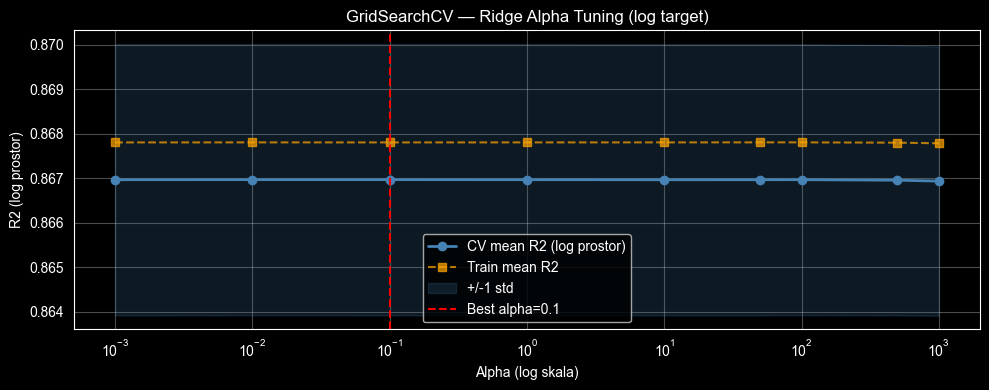

In [101]:
cv_results = pd.DataFrame(grid_search.cv_results_)
alphas   = cv_results['param_model__alpha'].astype(float)
mean_r2  = cv_results['mean_test_score']
std_r2   = cv_results['std_test_score']
train_r2 = cv_results['mean_train_score']

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(alphas, mean_r2, 'o-', color='steelblue', linewidth=2, label='CV mean R2 (log prostor)')
ax.semilogx(alphas, train_r2, 's--', color='orange', linewidth=1.5, alpha=0.7, label='Train mean R2')
ax.fill_between(alphas, mean_r2 - std_r2, mean_r2 + std_r2, alpha=0.2, color='steelblue', label='+/-1 std')
ax.axvline(best_alpha, color='red', linestyle='--', label=f'Best alpha={best_alpha}')
ax.set_xlabel('Alpha (log skala)')
ax.set_ylabel('R2 (log prostor)')
ax.set_title('GridSearchCV — Ridge Alpha Tuning (log target)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_alpha_tuning.png', dpi=150)
plt.show()


## 7. Evaluacija i Vizualizacije

### Metrike

| Metrika | Opis |
|---------|------|
| **MAE** | Prosecna apsolutna greska u EUR |
| **RMSE** | Penalizuje velika odstupanja |
| **R2** | Deo varijanse cene koji model objasnjava |
| **MAPE** | Relativna greska — intuitivnija od MAE za cene |
| **Smearing** | Duan's estimator za korekciju log-bias-a |

### O Smearing korekciji

```
smearing_factor = mean(exp(TRAIN reziduali u log prostoru))  <- uvek TRAIN, ne TEST
y_corrected     = exp(y_pred_log) * smearing_factor
```

> **Zasto TRAIN reziduali?**
> Smearing faktor mora biti izracunat na train skupu jer je to jedina informacija
> dostupna u produkciji pri predvidjanju novih podataka.
> Korisćenje test reziduala = data leakage + ne radi u deployment-u.


In [102]:
best_pipeline = grid_search.best_estimator_
y_pred_log    = best_pipeline.predict(X_test)
y_pred        = np.exp(y_pred_log)

# -- Standardne metrike ----------------------------------------------------
ridge_mae    = mean_absolute_error(y_test, y_pred)
ridge_rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
ridge_r2     = r2_score(y_test, y_pred)
ridge_r2_log = r2_score(y_test_log, y_pred_log)
ridge_mape   = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# -- Smearing korekcija (Duan, 1983) ----------------------------------------
y_train_pred_log    = best_pipeline.predict(X_train)
train_log_residuals = y_train_log - y_train_pred_log
smearing_factor     = np.mean(np.exp(train_log_residuals))

y_pred_smeared = y_pred * smearing_factor
smeared_mae    = mean_absolute_error(y_test, y_pred_smeared)
smeared_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_smeared))
smeared_r2     = r2_score(y_test, y_pred_smeared)
smeared_mape   = np.mean(np.abs((y_test - y_pred_smeared) / y_test)) * 100
smeared_bias   = (y_test - y_pred_smeared).mean()
raw_bias       = (y_test - y_pred).mean()

print('-- Evaluacija na TEST skupu (predikcije u EUR) ----')
print(f'  MAE             : {ridge_mae:>10,.2f} EUR')
print(f'  RMSE            : {ridge_rmse:>10,.2f} EUR')
print(f'  R2 (EUR prostor): {ridge_r2:>10.4f}')
print(f'  R2 (log prostor): {ridge_r2_log:>10.4f}')
print(f'  MAPE            : {ridge_mape:>10.2f}%')
print(f'  Sistematski bias: {raw_bias:>+10,.2f} EUR')
print()
print(f'-- Smearing korekcija (TRAIN-based, Duan 1983) ---')
print(f'  Smearing faktor (train-based): {smearing_factor:.6f}')
print(f'  MAE  (smeared) : {smeared_mae:>10,.2f} EUR')
print(f'  RMSE (smeared) : {smeared_rmse:>10,.2f} EUR')
print(f'  R2   (smeared) : {smeared_r2:>10.4f}')
print(f'  MAPE (smeared) : {smeared_mape:>10.2f}%')
print(f'  Bias (smeared) : {smeared_bias:>+10,.2f} EUR  <- cilj je ~0')
print()
print(f'  Min predikcije: {y_pred.min():,.2f} EUR  <- mora biti > 0')
print(f'  Max predikcije: {y_pred.max():,.2f} EUR')
print()

# Dijagnoza: da li smearing zaista pomaze?
print('-- Dijagnoza smearing efekta -----------------------------')
if smeared_mae < ridge_mae:
    print(f'  Smearing POBOLJSAVA MAE za {ridge_mae - smeared_mae:,.2f} EUR.')
    print('  Preporuka: koristi smeared predikcije u produkciji.')
else:
    print(f'  Smearing POGORSAVA MAE za {smeared_mae - ridge_mae:,.2f} EUR.')
    print(f'  Uzrok: log-reziduali nisu simetricno distribuisani — faktor ({smearing_factor:.4f})')
    print('  uvodi preveliku korekciju (over-correction). Raw predikcije su bolje.')
    print(f'  Preporuka: koristi raw exp(y_pred_log) | bias = {raw_bias:+,.0f} EUR')


-- Evaluacija na TEST skupu (predikcije u EUR) ----
  MAE             :   4,851.51 EUR
  RMSE            :  10,732.74 EUR
  R2 (EUR prostor):     0.8132
  R2 (log prostor):     0.8635
  MAPE            :      22.14%
  Sistematski bias:    +395.37 EUR

-- Smearing korekcija (TRAIN-based, Duan 1983) ---
  Smearing faktor (train-based): 1.051648
  MAE  (smeared) :   5,116.79 EUR
  RMSE (smeared) :  11,157.36 EUR
  R2   (smeared) :     0.7982
  MAPE (smeared) :      23.89%
  Bias (smeared) :    -867.77 EUR  <- cilj je ~0

  Min predikcije: 907.32 EUR  <- mora biti > 0
  Max predikcije: 490,508.13 EUR

-- Dijagnoza smearing efekta -----------------------------
  Smearing POGORSAVA MAE za 265.28 EUR.
  Uzrok: log-reziduali nisu simetricno distribuisani — faktor (1.0516)
  uvodi preveliku korekciju (over-correction). Raw predikcije su bolje.
  Preporuka: koristi raw exp(y_pred_log) | bias = +395 EUR


In [103]:
residuals = y_test - y_pred

print('-- Poredicenje: Baseline vs Ridge vs Ridge+Smearing -------')
print(f"{'':28s} {'Baseline':>12s} {'Ridge':>12s} {'Ridge+Smear':>13s}")
print(f"{'MAE (EUR)':28s} {baseline_mae:>12,.2f} {ridge_mae:>12,.2f} {smeared_mae:>13,.2f}")
print(f"{'RMSE (EUR)':28s} {baseline_rmse:>12,.2f} {ridge_rmse:>12,.2f} {smeared_rmse:>13,.2f}")
print(f"{'R2':28s} {baseline_r2:>12.4f} {ridge_r2:>12.4f} {smeared_r2:>13.4f}")
print(f"{'MAPE (%)':28s} {baseline_mape:>12.2f} {ridge_mape:>12.2f} {smeared_mape:>13.2f}")
print()
print(f'Sistematski bias (raw):     {residuals.mean():>+12,.2f} EUR')
print(f'Sistematski bias (smeared): {smeared_bias:>+12,.2f} EUR')
print()

ridge_improvement_r2  = ridge_r2 - baseline_r2
ridge_improvement_mae = baseline_mae - ridge_mae
print('-- Interpretacija: Ridge vs Baseline ---------------------')
print(f'  Delta-R2 : {ridge_improvement_r2:>+.4f}')
print(f'  Delta-MAE: {ridge_improvement_mae:>+,.2f} EUR')
print()
if abs(ridge_improvement_r2) < 0.001:
    print(f'ZAKLJUCAK: Ridge (alpha={best_alpha}) je prakticno identicanLinearRegression-u.')
    print(f'  Poboljsanje R2 od {ridge_improvement_r2:.4f} je statisticki zanemarljivo.')
    print(f'  Razlog: N={len(X_train):,} >> p=29 -> nema overfittinga, regularizacija nije potrebna.')
    print(f'  Train-CV gap od {overfit_gap:.4f} potvrduje ovu dijagnozu.')
    print('  Ridge bi bio korisniji sa znatno manjim skupom ili visoko-korelisanim featureima.')
else:
    print(f'ZAKLJUCAK: Ridge daje merljivo poboljsanje (Delta-R2={ridge_improvement_r2:+.4f}).')


-- Poredicenje: Baseline vs Ridge vs Ridge+Smearing -------
                                 Baseline        Ridge   Ridge+Smear
MAE (EUR)                        4,850.89     4,851.51      5,116.79
RMSE (EUR)                      10,727.80    10,732.74     11,157.36
R2                                 0.8134       0.8132        0.7982
MAPE (%)                            22.14        22.14         23.89

Sistematski bias (raw):          +395.37 EUR
Sistematski bias (smeared):      -867.77 EUR

-- Interpretacija: Ridge vs Baseline ---------------------
  Delta-R2 : -0.0002
  Delta-MAE: -0.62 EUR

ZAKLJUCAK: Ridge (alpha=0.1) je prakticno identicanLinearRegression-u.
  Poboljsanje R2 od -0.0002 je statisticki zanemarljivo.
  Razlog: N=191,875 >> p=29 -> nema overfittinga, regularizacija nije potrebna.
  Train-CV gap od 0.0008 potvrduje ovu dijagnozu.
  Ridge bi bio korisniji sa znatno manjim skupom ili visoko-korelisanim featureima.


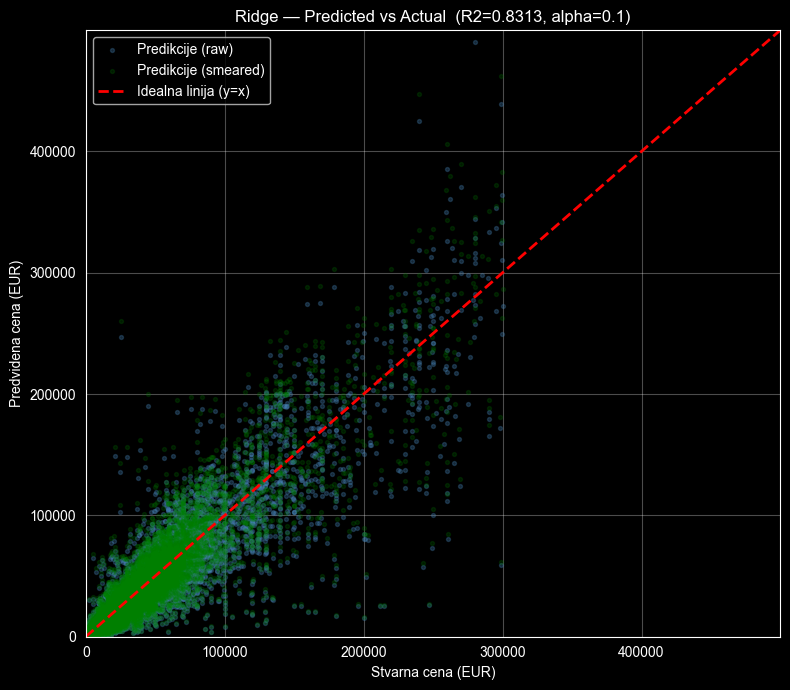

In [82]:
fig, ax = plt.subplots(figsize=(8, 7))
max_val = max(y_test.max(), y_pred.max()) * 1.02
ax.scatter(y_test, y_pred, alpha=0.3, s=8, color='steelblue', label='Predikcije (raw)')
ax.scatter(y_test, y_pred_smeared, alpha=0.2, s=8, color='green', label='Predikcije (smeared)')
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Idealna linija (y=x)')
ax.set_xlim(left=0, right=max_val)
ax.set_ylim(bottom=0, top=max_val)
ax.set_xlabel('Stvarna cena (EUR)')
ax.set_ylabel('Predvidena cena (EUR)')
ax.set_title(f'Ridge — Predicted vs Actual  (R2={ridge_r2:.4f}, alpha={best_alpha})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_pred_vs_actual.png', dpi=150)
plt.show()


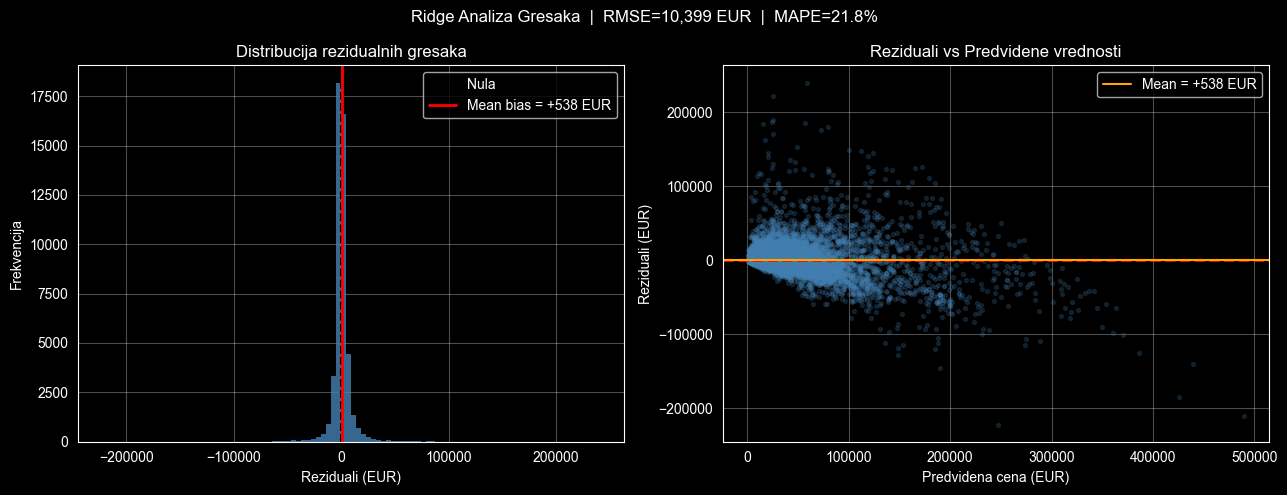

Srednja vrednost rezidualnih (bias): +537.80 EUR
Std rezidualnih:                      10,384.73 EUR


In [83]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(residuals, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.5, label='Nula')
axes[0].axvline(residuals.mean(), color='red', linestyle='-', linewidth=2,
                label=f'Mean bias = {residuals.mean():+,.0f} EUR')
axes[0].set_xlabel('Reziduali (EUR)')
axes[0].set_ylabel('Frekvencija')
axes[0].set_title('Distribucija rezidualnih gresaka')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_pred, residuals, alpha=0.2, s=8, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].axhline(residuals.mean(), color='orange', linestyle='-', linewidth=1.5,
                label=f'Mean = {residuals.mean():+,.0f} EUR')
axes[1].set_xlabel('Predvidena cena (EUR)')
axes[1].set_ylabel('Reziduali (EUR)')
axes[1].set_title('Reziduali vs Predvidene vrednosti')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Ridge Analiza Gresaka  |  RMSE={ridge_rmse:,.0f} EUR  |  MAPE={ridge_mape:.1f}%', fontsize=12)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_residuali.png', dpi=150)
plt.show()
print(f'Srednja vrednost rezidualnih (bias): {residuals.mean():+,.2f} EUR')
print(f'Std rezidualnih:                     {residuals.std():>10,.2f} EUR')


## 8. Analiza Gresaka po Cenovnom Segmentu

Agregatni MAPE od ~22% skriva bitne razlike izmedju trzisnih segmenata.
Model moze biti odlican za srednju klasu ali los za luksuzna vozila.

Ovde otkrivamo **gde** model gresi i **u kom smeru** (potcenjen vs precenjen).


-- Greska po cenovnom segmentu --------------
   Segment        N         MAE      MAPE        Bias  Smer
     < 10k    9,948       1,650      38.7%        -854  precenjen
   10k-20k   15,308       2,600      17.0%        +160  potcenjen
   20k-40k   16,673       4,539      16.1%        +404  potcenjen
   40k-80k    4,697      11,515      21.0%      +2,097  potcenjen
     > 80k    1,343      34,525      25.5%     +11,376  potcenjen


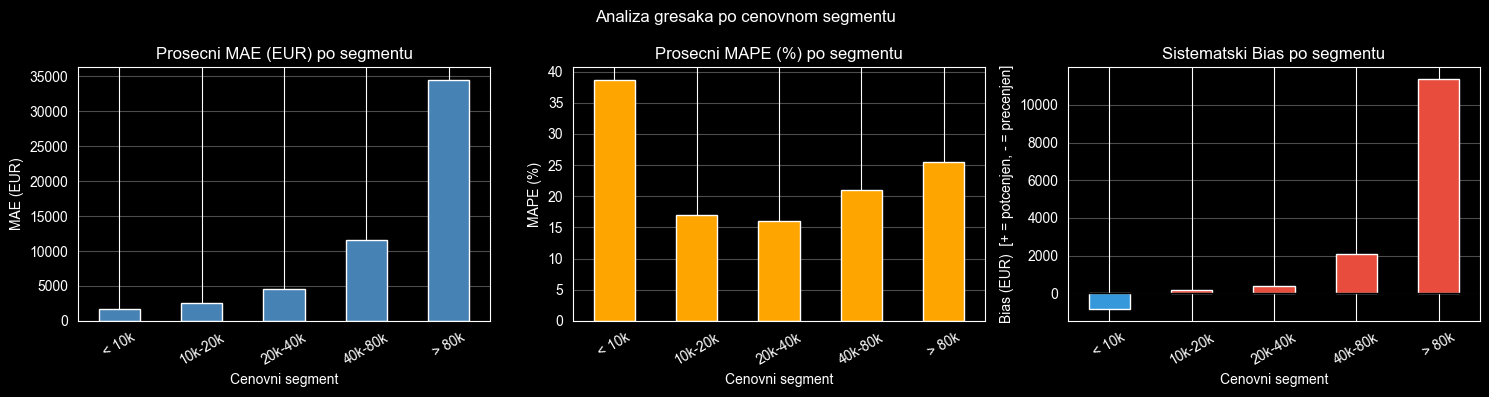

In [62]:
bins   = [0, 10_000, 20_000, 40_000, 80_000, float('inf')]
labels = ['< 10k', '10k-20k', '20k-40k', '40k-80k', '> 80k']

segment = pd.cut(y_test, bins=bins, labels=labels)
seg_df  = pd.DataFrame({
    'stvarna':    y_test.values,
    'predvidena': y_pred,
    'reziduali':  residuals.values,
    'abs_greska': np.abs(residuals.values),
    'pct_greska': np.abs((y_test.values - y_pred) / y_test.values) * 100,
    'segment':    segment.values
})

seg_stats = seg_df.groupby('segment', observed=True).agg(
    n=('stvarna', 'count'),
    mean_mae=('abs_greska', 'mean'),
    mean_mape=('pct_greska', 'mean'),
    mean_bias=('reziduali', 'mean')
).round(2)

print('-- Greska po cenovnom segmentu --------------')
print(f"{'Segment':>10s}  {'N':>7s}  {'MAE':>10s}  {'MAPE':>8s}  {'Bias':>10s}  Smer")
for seg, row in seg_stats.iterrows():
    bias_dir = 'potcenjen' if row['mean_bias'] > 0 else 'precenjen'
    print(f"  {seg:>8s}  {row['n']:>7,.0f}  {row['mean_mae']:>10,.0f}  "
          f"{row['mean_mape']:>8.1f}%  {row['mean_bias']:>+10,.0f}  {bias_dir}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

seg_stats['mean_mae'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Prosecni MAE (EUR) po segmentu')
axes[0].set_xlabel('Cenovni segment')
axes[0].set_ylabel('MAE (EUR)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.3, axis='y')

seg_stats['mean_mape'].plot(kind='bar', ax=axes[1], color='orange', edgecolor='white')
axes[1].set_title('Prosecni MAPE (%) po segmentu')
axes[1].set_xlabel('Cenovni segment')
axes[1].set_ylabel('MAPE (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.3, axis='y')

colors_bias = ['#e74c3c' if v > 0 else '#3498db' for v in seg_stats['mean_bias']]
seg_stats['mean_bias'].plot(kind='bar', ax=axes[2], color=colors_bias, edgecolor='white')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title('Sistematski Bias po segmentu')
axes[2].set_xlabel('Cenovni segment')
axes[2].set_ylabel('Bias (EUR)  [+ = potcenjen, - = precenjen]')
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Analiza gresaka po cenovnom segmentu', fontsize=12)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_greska_po_segmentu.png', dpi=150)
plt.show()


## 9. Interpretacija Koeficijenata

Koeficijenti su u **log prostoru** (model treniran na `log(price)`).

| Koeficijent | exp(koef) | Interpretacija |
|-------------|-----------|----------------|
| +0.3 | 1.35 | Feature povecava cenu za ~35% |
| -0.2 | 0.82 | Feature smanjuje cenu za ~18% |
| ~0   | ~1   | Minimalan uticaj |

> Koeficijenti su interpretabilni samo ceteris paribus i na skaliranim podacima.


In [63]:
ridge_model = best_pipeline.named_steps['model']
prep        = best_pipeline.named_steps['preprocessor']

te_names  = TARGET_ENC_COLS
ohe_names = list(prep.named_transformers_['ohe'].named_steps['encoder'].get_feature_names_out(OHE_COLS))
num_names = NUM_COLS

all_feature_names = te_names + ohe_names + num_names
coef = ridge_model.coef_

coef_df = pd.DataFrame({
    'Feature':     all_feature_names,
    'Koeficijent': coef,
    'Exp_koef':    np.exp(coef),
    'Uticaj_pct':  (np.exp(coef) - 1) * 100
}).sort_values('Koeficijent', key=abs, ascending=False)

print(f'Broj feature-a: {len(all_feature_names)}')
print(f'Intercept (log EUR): {ridge_model.intercept_:.4f}  -> exp = {np.exp(ridge_model.intercept_):,.2f} EUR')
print()
print('Top 15 feature-a po apsolutnoj vrednosti koeficijenta:')
print(coef_df[['Feature', 'Koeficijent', 'Exp_koef', 'Uticaj_pct']].head(15).to_string(index=False))
print()
print('-- Napomena o kontraintuitivnim koeficijentima ----------')
print('  fuel_consumption_l_100km (+): Veca potrosnja -> veca cena?')
print('    Objasnjenje: multikolinearnost — veci motori troše vise ali i kostaju vise.')
print('    Koeficijent reflektuje korelaciju sa power_kw, ne direktan efekat potrosnje.')
print()
print('  fuel_type_electric (-): Elektricni auti tipicno kostaju vise, koef negativan?')
print('    Objasnjenje: kompozicioni efekat — dataset verovatno sadrzi mnogo jeftinijih')
print('    starijih elektricnih vozila koji spustaju prosek kategorije u TargetEncoder-u.')


Broj feature-a: 29
Intercept (log EUR): 9.7958  -> exp = 17,958.93 EUR

Top 15 feature-a po apsolutnoj vrednosti koeficijenta:
                 Feature  Koeficijent  Exp_koef  Uticaj_pct
                 car_age    -0.336459  0.714295  -28.570509
                power_kw     0.258485  1.294966   29.496640
           mileage_in_km    -0.234822  0.790712  -20.928842
                   model     0.163405  1.177513   17.751339
        fuel_type_diesel     0.106341  1.112201   11.220122
transmission_type_manual    -0.075340  0.927428   -7.257223
                   brand     0.047845  1.049009    4.900857
fuel_consumption_l_100km     0.043431  1.044388    4.438808
             color_black    -0.034076  0.966498   -3.350223
              color_grey    -0.030397  0.970061   -2.993938
              color_blue    -0.027703  0.972677   -2.732260
             color_white    -0.024533  0.975766   -2.423412
            color_silver    -0.021413  0.978814   -2.118556
               color_red    -0.02

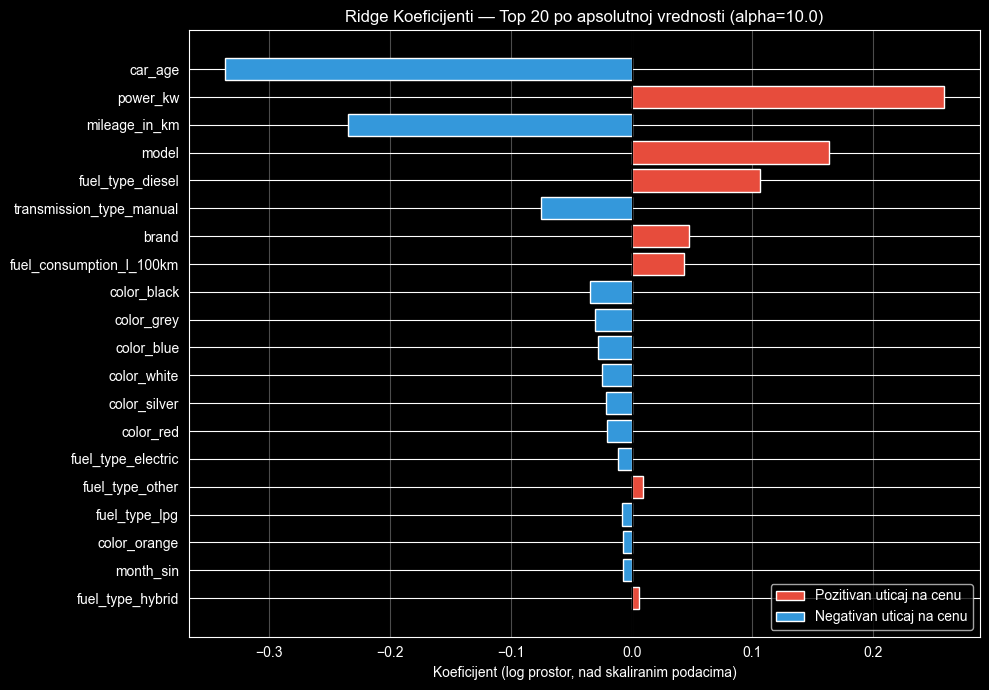

In [64]:
top_n    = 20
top_coef = coef_df.head(top_n)
colors   = ['#e74c3c' if v > 0 else '#3498db' for v in top_coef['Koeficijent']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_coef['Feature'], top_coef['Koeficijent'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Koeficijent (log prostor, nad skaliranim podacima)')
ax.set_title(f'Ridge Koeficijenti — Top {top_n} po apsolutnoj vrednosti (alpha={best_alpha})')
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Pozitivan uticaj na cenu'),
                   Patch(facecolor='#3498db', label='Negativan uticaj na cenu')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_koeficijenti.png', dpi=150)
plt.show()


## 10. Čuvanje Pipeline-a

### Sta se cuva

| Fajl | Sadrzaj | Napomena |
|------|---------|----------|
| `ridge_pipeline.pkl` | Kompletan sklearn Pipeline | Preprocessor + Ridge model |
| `ridge_smearing_factor.pkl` | Duan smearing faktor | Izracunat na **train** rezidualima |

```python
import datetime, numpy as np, pandas as pd, joblib

pipeline        = joblib.load('models/ridge_pipeline.pkl')
smearing_factor = joblib.load('models/ridge_smearing_factor.pkl')  # train-based

def predict_price(brand, model_name, color, power_kw,
                  transmission_type, fuel_type, fuel_consumption_l_100km,
                  mileage_in_km, registration_month, year):
    car_age   = datetime.datetime.now().year - year
    month_sin = np.sin(2 * np.pi * registration_month / 12)
    month_cos = np.cos(2 * np.pi * registration_month / 12)
    X_input = pd.DataFrame([{
        'brand': brand, 'model': model_name, 'color': color,
        'power_kw': power_kw, 'transmission_type': transmission_type,
        'fuel_type': fuel_type, 'fuel_consumption_l_100km': fuel_consumption_l_100km,
        'mileage_in_km': mileage_in_km, 'car_age': car_age,
        'month_sin': month_sin, 'month_cos': month_cos
    }])
    return np.exp(pipeline.predict(X_input)[0])
```


In [65]:
pipeline_path = MODELS_DIR / 'ridge_pipeline.pkl'
joblib.dump(best_pipeline, pipeline_path)
print(f'Pipeline sacuvan: {pipeline_path}')

loaded_pipeline = joblib.load(pipeline_path)
y_pred_verify   = np.exp(loaded_pipeline.predict(X_test))
r2_verify       = r2_score(y_test, y_pred_verify)
status = 'Uspelo' if abs(r2_verify - ridge_r2) < 1e-6 else 'NEUSPELO!'
print(f'Verifikacija (R2 na test skupu, reload): {r2_verify:.4f}  {status}')

# FIX: Cuvamo smearing faktor izracunat na TRAIN skupu (ne test kao pre)
smearing_path = MODELS_DIR / 'ridge_smearing_factor.pkl'
joblib.dump(smearing_factor, smearing_path)
print(f'Smearing faktor sacuvan (train-based): {smearing_path}')
print(f'Vrednost: {smearing_factor:.6f}')
print('Napomena: train-based smearing faktor je bezbedan za produkciju.')


Pipeline sacuvan: D:\Work\used-car-price-prediction\models\ridge_pipeline.pkl
Verifikacija (R2 na test skupu, reload): 0.8313  Uspelo
Smearing faktor sacuvan (train-based): D:\Work\used-car-price-prediction\models\ridge_smearing_factor.pkl
Vrednost: 1.052050
Napomena: train-based smearing faktor je bezbedan za produkciju.


## 11. PCA Eksperiment

Testiramo da li redukcija dimenzionalnosti pre Ridge-a poboljsava performanse.
PCA zadrzava komponente koje objasanjavaju **95% varijanse** feature prostora.


In [66]:
pca_pipeline = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('pca',          PCA(n_components=0.95, random_state=42)),
    ('model',        Ridge(alpha=best_alpha, random_state=42))
])

pca_pipeline.fit(X_train, y_train_log)
y_pred_pca_log = pca_pipeline.predict(X_test)
y_pred_pca     = np.exp(y_pred_pca_log)

pca_r2   = r2_score(y_test, y_pred_pca)
pca_mae  = mean_absolute_error(y_test, y_pred_pca)
pca_rmse = np.sqrt(mean_squared_error(y_test, y_pred_pca))
pca_mape = np.mean(np.abs((y_test - y_pred_pca) / y_test)) * 100
n_comp   = pca_pipeline.named_steps['pca'].n_components_
n_total  = pca_pipeline.named_steps['pca'].n_features_in_
dim_red  = (1 - n_comp / n_total) * 100

print(f'PCA komponente (95% varijanse): {n_comp} od {n_total} ukupnih feature-a')
print(f'Redukcija dimenzionalnosti: {dim_red:.0f}%  ({n_total} -> {n_comp})')
print()
print('-- Poredicenje: Original vs PCA ---------------------')
print(f"{'':20s} {'Original':>12s} {'PCA':>12s} {'Delta':>8s}")
print(f"{'MAE (EUR)':20s} {ridge_mae:>12,.2f} {pca_mae:>12,.2f} {pca_mae - ridge_mae:>+8,.2f}")
print(f"{'RMSE (EUR)':20s} {ridge_rmse:>12,.2f} {pca_rmse:>12,.2f} {pca_rmse - ridge_rmse:>+8,.2f}")
print(f"{'R2':20s} {ridge_r2:>12.4f} {pca_r2:>12.4f} {pca_r2 - ridge_r2:>+8.4f}")
print(f"{'MAPE (%)':20s} {ridge_mape:>12.2f} {pca_mape:>12.2f} {pca_mape - ridge_mape:>+8.2f}")
print()
diff = ridge_r2 - pca_r2
if diff > 0:
    print(f'Zakljucak: PCA model je LOSIJI za Delta-R2={abs(diff):.4f}')
    print('   PCA uvodi gubitak informacija koji nije kompenzovan redukcijom suma.')
else:
    print(f'Zakljucak: PCA model je BOLJI za Delta-R2={abs(diff):.4f}')
print('Finalni model: Ridge u ORIGINALNOM prostoru feature-a.')
print()


print('-- Dijagnoza redukcije dimenzionalnosti -------------')
if dim_red < 25:
    print(f'  PCA zadrzala {n_comp}/{n_total} dimenzija ({n_comp/n_total*100:.0f}% originala).')
    print('  Ovo NIJE kompaktan feature prostor.')
    print('  Feature-i su nisko-korelirani i informaciono bogati — svaki nosi znacajan')
    print('  deo varijanse koji ne moze biti eliminisan bez gubitka informacija.')
    print('  PCA je skoro bezkorisna za ovaj dataset.')
elif dim_red < 60:
    print(f'  Umerena redukcija: {n_comp}/{n_total} -> {n_comp/n_total*100:.0f}% originala.')
else:
    print(f'  Znacajna redukcija: samo {n_comp/n_total*100:.0f}% dimenzija potrebno.')
    print('  Feature prostor je kompaktan — feature-i su visoko-korelirani.')


PCA komponente (95% varijanse): 23 od 29 ukupnih feature-a
Redukcija dimenzionalnosti: 21%  (29 -> 23)

-- Poredicenje: Original vs PCA ---------------------
                         Original          PCA    Delta
MAE (EUR)                4,843.50     5,286.59  +443.09
RMSE (EUR)              10,398.07    10,507.81  +109.73
R2                         0.8313       0.8277  -0.0036
MAPE (%)                    21.79        24.41    +2.61

Zakljucak: PCA model je LOSIJI za Delta-R2=0.0036
   PCA uvodi gubitak informacija koji nije kompenzovan redukcijom suma.
Finalni model: Ridge u ORIGINALNOM prostoru feature-a.

-- Dijagnoza redukcije dimenzionalnosti -------------
  PCA zadrzala 23/29 dimenzija (79% originala).
  Ovo NIJE kompaktan feature prostor.
  Feature-i su nisko-korelirani i informaciono bogati — svaki nosi znacajan
  deo varijanse koji ne moze biti eliminisan bez gubitka informacija.
  PCA je skoro bezkorisna za ovaj dataset.


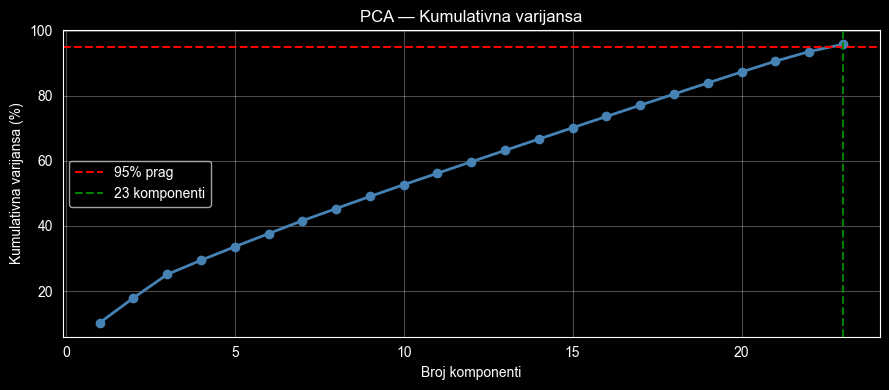

Sa 23 PCA komponenti objasnjeno je 95% varijanse od ukupno 23 feature-a.
Potrebno 100% originalnih dimenzija -> prostor je visoko-dimenzionalan.
PCA nije efikasno reduktivna — feature-i su nisko-korelirani i informaciono bogati.


In [67]:
pca_step = pca_pipeline.named_steps['pca']
cumvar   = np.cumsum(pca_step.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, 'o-', color='steelblue', linewidth=2)
ax.axhline(95, color='red', linestyle='--', label='95% prag')
ax.axvline(n_comp, color='green', linestyle='--', label=f'{n_comp} komponenti')
ax.set_xlabel('Broj komponenti')
ax.set_ylabel('Kumulativna varijansa (%)')
ax.set_title('PCA — Kumulativna varijansa')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_pca_varijansa.png', dpi=150)
plt.show()
print(f'Sa {n_comp} PCA komponenti objasnjeno je 95% varijanse od ukupno {len(cumvar)} feature-a.')
if n_comp / len(cumvar) >= 0.75:
    print(f'Potrebno {n_comp/len(cumvar)*100:.0f}% originalnih dimenzija -> prostor je visoko-dimenzionalan.')
    print('PCA nije efikasno reduktivna — feature-i su nisko-korelirani i informaciono bogati.')
else:
    print(f'Relativno kompaktan prostor: {n_comp/len(cumvar)*100:.0f}% dimenzija zadrzano.')
